# 「Python基礎の基礎」の補足事項と例題
「[ゼロからのPython入門講座 ― Python基礎の基礎](https://www.python.jp/train/type_and_func/index.html)」を読んでから取り組んでください．

（元ファイルは[こちら](tafExercise2.ipynb)）

## import についての補足

```python
from A import x, y, ...     # モジュール A から x, y, ... をインポートする
```

- `x`, `y` の呼び出しは，`A.x` や `A.y` のように，`A.` を付けなくてもよい
- `x`, `y` ... 以外はインポートされない
  - 通常の `import A` の場合は，`A` で定義されているすべてがインポートされる


In [1]:
# モジュール math から sqrt（平方根関数）をインポートする
from math import sqrt
sqrt(3)     # math. を付けなくてもよい

1.7320508075688772

In [2]:
# モジュール math から cos（余弦関数）と pi（円周率）をインポートする
from math import cos, pi
print(cos(pi/3))
print(sin(pi/3))    # sin はインポートしていないのでエラーになる

0.5000000000000001


NameError: name 'sin' is not defined

In [3]:
# こうすれば大丈夫
from math import sin, cos, pi
print(cos(pi/3))
print(sin(pi/3))

0.5000000000000001
0.8660254037844386


```python
import A as B       # モジュール A を B という名前でインポートする
```

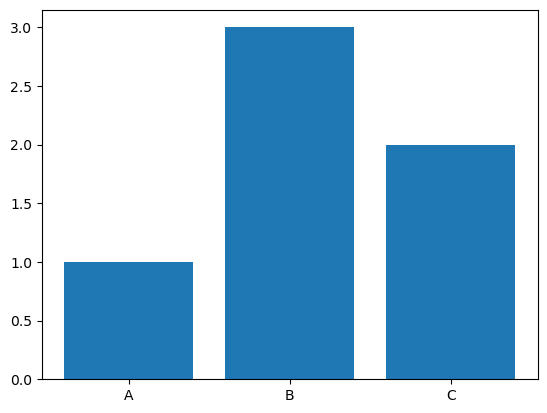

In [4]:
import matplotlib.pyplot as plt
plt.bar(['A', 'B', 'C'], [1, 3, 2])
plt.show()

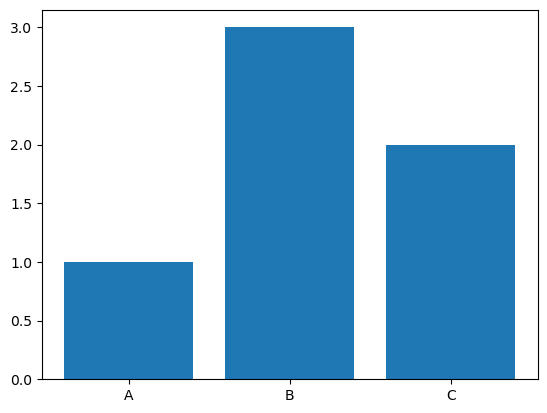

In [5]:
# こう書くよりも大分楽
import matplotlib.pyplot
matplotlib.pyplot.bar(['A', 'B', 'C'], [1, 3, 2])
matplotlib.pyplot.show()

- `as` の後の名前は自由に付けられるが，あまり勝手につけると，
  第三者が読みづらくなったり，後で読む際にどのモジュールだったかわからなくなったりする．
- なので，慣習的に標準が定まっているものは，その慣習に従うのがよい．
- 上の例の `matplotlib.pyplot` を `plt` と名付けるのも，慣習的な標準になっている．

## 例題

**例題1**

- 身長 $h$ (m)，体重 $w$ (kg)から BMI $b$，標準体重 $s$ (kg)，肥満度 $r$ (%) を計算して表示させてみよう

  $$
  \left\{\begin{array}{rcl}
  b &=& \displaystyle\frac{w}{h^2}\\\\
  s &=& 22 \times h^2\\\\
  r &=& \displaystyle100\times\frac{w-s}{s}
  \end{array}\right.
  $$

- できた人は，結果を小数第1位までに丸めて表示させてみよう．  
  - ［ヒント］[組み込み関数](https://docs.python.org/ja/3.12/library/functions.html) の [`round(…)`関数](https://docs.python.org/ja/3.12/library/functions.html#round) を用いる．

In [6]:
# tafCode1:

h = 1.6 #(m)
w = 55  #(kg)
# 上の値をもとに計算してみよう

b = w / (h * h)
s = 22 * h * h
r = 100 * (w-s) / s

print("b =", b)
print("s =", s)
print("r =", r)

b = 21.484374999999996
s = 56.32000000000001
r = -2.343750000000013


In [7]:
# tafCode1-2:

h = 1.6 #(m)
w = 55  #(kg)
# 上の値をもとに計算してみよう

b = w / (h * h)
s = 22 * h * h
r = 100 * (w-s) / s

print("BMI　　　=", round(b, 1))
print("標準体重 =", round(s, 1), "kg")
print("肥満度　 =", round(r, 1), "%")

BMI　　　= 21.5
標準体重 = 56.3 kg
肥満度　 = -2.3 %


**例題2**

- 二次方程式 $ax^2+bx+c=0$ の係数 $a,\,b,\,c$ から解 $\alpha,\,\beta$ を計算して表示させてみよう．

  $$
  \left\{\begin{array}{rcl}
  \alpha &=& \displaystyle\frac{-b+\sqrt{b^2 - 4ac}}{2a}\\\\
  \beta  &=& \displaystyle\frac{-b-\sqrt{b^2 - 4ac}}{2a}
  \end{array}\right.
  $$

  - ［ヒント］平方根の計算には，[mathモジュール](https://docs.python.org/ja/3.12/library/math.html) の [`math.sqrt(…)`関数](https://docs.python.org/ja/3.12/library/math.html#math.sqrt) を用いるとよい．  

- できた人は，計算ステップ$^{[1]}$をできるだけ少なくなるように書き直してみよう．  
  - ［ヒント］変数と代入をうまく使う．
  ___
  $[1]$：+, -, *, / の二項演算，-（マイナス）の単項演算，べき乗計算，関数の呼び出し，代入 のそれぞれの1回を1ステップとして合計する．

In [8]:
# tafCode2:

a = 5
b = -2
c = -3
# 上の値をもとに計算してみよう

from math import sqrt
alpha = (-b + sqrt(b*b - 4*a*c)) / (2*a)
beta  = (-b - sqrt(b*b - 4*a*c)) / (2*a)

print(alpha, beta)

# 20step（a,b,c への代入を除く）

1.0 -0.6


In [9]:
# tafCode2-1:

a = 5
b = -2
c = -3
# 上の値をもとに計算してみよう

from math import sqrt
sqrtD = sqrt(b*b - 4*a*c)
alpha = (-b + sqrtD) / (2*a)
beta  = (-b - sqrtD) / (2*a)

print(alpha, beta)

# 16step（a,b,c への代入を除く）

1.0 -0.6


In [10]:
# tafCode2-2:

a = 5
b = -2
c = -3
# 上の値をもとに計算してみよう

from math import sqrt

b2 = b / (2*a)
s = sqrt(b2*b2 - c/a)
alpha = -b2 + s
beta  = -b2 - s

print(alpha, beta)

# 14step（a,b,c への代入を除く）... ちょっと誤差が出ますが

1.0 -0.6000000000000001


**補足事項**
- `x,y = 1,2` のような形の代入文を用いると，2つ（以上）の変数に同時に代入できる． 

In [11]:
# 例
x,y = 1,2       # x=1 と y=2 を実行するのと同じ
print(x,y)      # x と y を順に表示する
x,y = y,x       # x と y を入れ替えることもできる
print(x,y)
x,y,z = 1,2,3   # 3つ以上も可
print(x,y,z)
x,y,z = y,z,x   # 3つを順繰りに入れ替える
print(x,y,z)
x,y,z = y,z,x
print(x,y,z)
x,y,z = y,z,x
print(x,y,z)

1 2
2 1
1 2 3
2 3 1
3 1 2
1 2 3
